# **FYP2**

# **SECTION 1: INSTALLATION & IMPORTS**



In [1]:
!pip install -q optuna shap scikit-learn matplotlib seaborn plotly

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, roc_auc_score,
    classification_report
)
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    BertTokenizerFast, BertForSequenceClassification,
    Trainer, TrainingArguments
)
import optuna
import shap
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Create results directory
Path("./results").mkdir(exist_ok=True)
Path("./plots").mkdir(exist_ok=True)
Path("./models").mkdir(exist_ok=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 21.5 MB/s eta 0:00:00


# **importing google drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================================
# SECTION 2: DATA LOADING (Keep your existing code)
# ============================================================================

print("=" * 80)
print("LOADING DATASET")
print("=" * 80)

# Load your combined dataset
all_df = pd.read_csv('/content/drive/MyDrive/FYP Datasets/combined_fake_news_3.csv')

# Add url column if missing
if 'url' not in all_df.columns:
    all_df['url'] = ""

# Prepare metadata
meta = all_df[['source', 'url']] if 'source' in all_df.columns else all_df[['source']]

# Prepare features and labels
X = all_df['text'].fillna("").astype(str)
y = all_df['label']

print(f"Total samples: {len(X)}")
print(f"Label distribution:\n{y.value_counts()}")

# Split data: 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp, meta_train, meta_temp = train_test_split(
    X, y, meta, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test, meta_val, meta_test = train_test_split(
    X_temp, y_temp, meta_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nSplit sizes:")
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ============================================================================
# SECTION 3: BASELINE MODELS
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 3: BASELINE MODELS")
print("=" * 80)

# -----------------------------------------------------------------------------
# 3.1: TF-IDF + Logistic Regression
# -----------------------------------------------------------------------------

print("\n[3.1] Training TF-IDF + Logistic Regression...")

# Vectorize text
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec, lr_rec, lr_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_lr, average='binary'
)

print(f"LR Results - Acc: {lr_acc:.4f}, F1: {lr_f1:.4f}, "
      f"Prec: {lr_prec:.4f}, Rec: {lr_rec:.4f}")

# -----------------------------------------------------------------------------
# 3.2: TF-IDF + Linear SVM
# -----------------------------------------------------------------------------

print("\n[3.2] Training TF-IDF + Linear SVM...")

svm_model = LinearSVC(max_iter=1000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, y_pred_svm)
svm_prec, svm_rec, svm_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_svm, average='binary'
)

print(f"SVM Results - Acc: {svm_acc:.4f}, F1: {svm_f1:.4f}, "
      f"Prec: {svm_prec:.4f}, Rec: {svm_rec:.4f}")

# -----------------------------------------------------------------------------
# 3.3: BERT Baseline
# -----------------------------------------------------------------------------

print("\n[3.3] Training BERT Baseline...")

class NewsDataset(Dataset):
    def __init__(self, encodings, labels, meta=None):
        self.encodings = encodings
        self.labels = list(labels)
        self.meta = meta.reset_index(drop=True) if meta is not None else None

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Tokenize for BERT
bert_tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
MAX_LEN = 256

bert_train_encodings = bert_tokenizer(
    list(X_train), truncation=True, padding=True, max_length=MAX_LEN
)
bert_val_encodings = bert_tokenizer(
    list(X_val), truncation=True, padding=True, max_length=MAX_LEN
)
bert_test_encodings = bert_tokenizer(
    list(X_test), truncation=True, padding=True, max_length=MAX_LEN
)

bert_train_dataset = NewsDataset(bert_train_encodings, y_train)
bert_val_dataset = NewsDataset(bert_val_encodings, y_val)
bert_test_dataset = NewsDataset(bert_test_encodings, y_test)

# Train BERT
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
)

bert_training_args = TrainingArguments(
    output_dir='./results/bert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",  # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_val_dataset,
    compute_metrics=compute_metrics
)

bert_trainer.train()

# Evaluate BERT
bert_results = bert_trainer.evaluate(bert_test_dataset)
print(f"\nBERT Results - Acc: {bert_results['eval_accuracy']:.4f}, "
      f"F1: {bert_results['eval_f1']:.4f}")

# Save BERT training history
bert_history = bert_trainer.state.log_history

LOADING DATASET
Total samples: 80771
Label distribution:
label
1    47366
0    33405
Name: count, dtype: int64

Split sizes:
Train: 64616, Val: 8077, Test: 8078

SECTION 3: BASELINE MODELS

[3.1] Training TF-IDF + Logistic Regression...
LR Results - Acc: 0.8674, F1: 0.8913, Prec: 0.8580, Rec: 0.9274

[3.2] Training TF-IDF + Linear SVM...
SVM Results - Acc: 0.8658, F1: 0.8883, Prec: 0.8674, Rec: 0.9103

[3.3] Training BERT Baseline...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.223300,0.213504,0.890677,0.909981,0.879929,0.942157
2,0.193200,0.238928,0.896249,0.913412,0.894556,0.933080
3,0.097000,0.353313,0.894144,0.911279,0.896122,0.926958



BERT Results - Acc: 0.8986, F1: 0.9148


In [5]:

# ============================================================================
# SECTION 4: DISTILBERT WITH CROSS-VALIDATION & HYPERPARAMETER TUNING
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 4: DISTILBERT OPTIMIZATION")
print("=" * 80)

# -----------------------------------------------------------------------------
# 4.1: Hyperparameter Search with Optuna
# -----------------------------------------------------------------------------

print("\n[4.1] Running Hyperparameter Search...")

distilbert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

distilbert_train_encodings = distilbert_tokenizer(
    list(X_train), truncation=True, padding=True, max_length=MAX_LEN
)
distilbert_val_encodings = distilbert_tokenizer(
    list(X_val), truncation=True, padding=True, max_length=MAX_LEN
)
distilbert_test_encodings = distilbert_tokenizer(
    list(X_test), truncation=True, padding=True, max_length=MAX_LEN
)

distilbert_train_dataset = NewsDataset(distilbert_train_encodings, y_train)
distilbert_val_dataset = NewsDataset(distilbert_val_encodings, y_val)
distilbert_test_dataset = NewsDataset(distilbert_test_encodings, y_test)

def objective(trial):
    lr = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    epochs = trial.suggest_int("epochs", 2, 4)

    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f'./results/optuna_trial_{trial.number}',
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=0.01,
        eval_strategy="epoch",  # Changed from evaluation_strategy
        save_strategy="no",
        logging_steps=100,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=distilbert_train_dataset,
        eval_dataset=distilbert_val_dataset,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_results = trainer.evaluate()

    return eval_results['eval_f1']

# Run Optuna study (reduced trials for faster execution)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)

print(f"\nBest hyperparameters: {study.best_params}")
print(f"Best F1 score: {study.best_value:.4f}")

best_params = study.best_params

# -----------------------------------------------------------------------------
# 4.2: Train Final DistilBERT with Best Hyperparameters
# -----------------------------------------------------------------------------

print("\n[4.2] Training Final DistilBERT Model...")

distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)

final_training_args = TrainingArguments(
    output_dir='./results/distilbert_final',
    num_train_epochs=best_params['epochs'],
    per_device_train_batch_size=best_params['batch_size'],
    per_device_eval_batch_size=best_params['batch_size'],
    learning_rate=best_params['learning_rate'],
    weight_decay=0.01,
    eval_strategy="epoch",  # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    report_to="none"
)

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=final_training_args,
    train_dataset=distilbert_train_dataset,
    eval_dataset=distilbert_val_dataset,
    compute_metrics=compute_metrics
)

distilbert_trainer.train()

# Evaluate on test set
distilbert_results = distilbert_trainer.evaluate(distilbert_test_dataset)
print(f"\nDistilBERT Results - Acc: {distilbert_results['eval_accuracy']:.4f}, "
      f"F1: {distilbert_results['eval_f1']:.4f}")

# Save training history
distilbert_history = distilbert_trainer.state.log_history

# Save best model
distilbert_trainer.save_model("./models/distilbert_best")
distilbert_tokenizer.save_pretrained("./models/distilbert_best")

# -----------------------------------------------------------------------------
# 4.3: Cross-Validation for DistilBERT
# -----------------------------------------------------------------------------

print("\n[4.3] Running 5-Fold Cross-Validation...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\nFold {fold}/5...")

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]

    fold_train_encodings = distilbert_tokenizer(
        list(X_fold_train), truncation=True, padding=True, max_length=MAX_LEN
    )
    fold_val_encodings = distilbert_tokenizer(
        list(X_fold_val), truncation=True, padding=True, max_length=MAX_LEN
    )

    fold_train_dataset = NewsDataset(fold_train_encodings, y_fold_train)
    fold_val_dataset = NewsDataset(fold_val_encodings, y_fold_val)

    fold_model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=2
    )

    fold_args = TrainingArguments(
        output_dir=f'./results/cv_fold_{fold}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        report_to="none"
    )

    fold_trainer = Trainer(
        model=fold_model,
        args=fold_args,
        train_dataset=fold_train_dataset,
        eval_dataset=fold_val_dataset,
        compute_metrics=compute_metrics
    )

    fold_trainer.train()
    fold_results = fold_trainer.evaluate()
    cv_scores.append(fold_results['eval_f1'])
    print(f"Fold {fold} F1: {fold_results['eval_f1']:.4f}")

print(f"\nCross-Validation Results:")
print(f"Mean F1: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# ============================================================================
# SECTION 5: MODEL OPTIMIZATION
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 5: MODEL OPTIMIZATION")
print("=" * 80)

# -----------------------------------------------------------------------------
# 5.1: Model Size Before Optimization
# -----------------------------------------------------------------------------

print("\n[5.1] Measuring Original Model Size...")

def get_model_size_mb(model):
    torch.save(model.state_dict(), "temp_model.pt")
    size_mb = Path("temp_model.pt").stat().st_size / (1024 * 1024)
    Path("temp_model.pt").unlink()
    return size_mb

original_size = get_model_size_mb(distilbert_model)
print(f"Original DistilBERT size: {original_size:.2f} MB")




SECTION 4: DISTILBERT OPTIMIZATION

[4.1] Running Hyperparameter Search...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Fold 4 F1: 0.9080

Fold 5/5...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
500,0.299900
1000,0.246600
1500,0.236000
2000,0.234800
2500,0.223500
3000,0.223400
3500,0.203500
4000,0.180100
4500,0.171800
5000,0.188100


Fold 5 F1: 0.9116

Cross-Validation Results:
Mean F1: 0.9119 ± 0.0025

SECTION 5: MODEL OPTIMIZATION

[5.1] Measuring Original Model Size...
Original DistilBERT size: 255.45 MB

[5.2] Applying Dynamic Quantization...
Quantized DistilBERT size: 132.29 MB
Size reduction: 48.2%

[5.3] Measuring Inference Performance...
CPU Latency (Original): 60.56 ± 24.87 ms


RuntimeError: apply_dynamic is not implemented for this packed parameter type

In [6]:
# -----------------------------------------------------------------------------
# 5.2: Dynamic Quantization (safe version)
# -----------------------------------------------------------------------------
print("\n[5.2] Applying Dynamic Quantization...")

distilbert_quantized = torch.quantization.quantize_dynamic(
    distilbert_model, {nn.Linear}, dtype=torch.qint8
)

quantized_size = get_model_size_mb(distilbert_quantized)
print(f"Quantized DistilBERT size: {quantized_size:.2f} MB")
print(f"Size reduction: {(1 - quantized_size/original_size)*100:.1f}%")

# Save quantized model
torch.save(distilbert_quantized.state_dict(), "./models/distilbert_quantized.pt")

# -----------------------------------------------------------------------------
# 5.3: Inference Latency & Throughput (skip quantized latency if unsupported)
# -----------------------------------------------------------------------------
print("\n[5.3] Measuring Inference Performance...")

def measure_latency(model, dataset, device, n_samples=50):
    model.to(device)
    model.eval()
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
    latencies = []
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= n_samples:
                break
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            start = time.time()
            _ = model(input_ids=input_ids, attention_mask=attention_mask)
            latencies.append((time.time() - start) * 1000)
    return np.mean(latencies), np.std(latencies)

# CPU latency for original model
cpu_latency, cpu_std = measure_latency(distilbert_model, distilbert_test_dataset, 'cpu', n_samples=50)
print(f"CPU Latency (Original): {cpu_latency:.2f} ± {cpu_std:.2f} ms")

# Try quantized latency, but skip if unsupported
try:
    cpu_latency_quant, cpu_std_quant = measure_latency(distilbert_quantized, distilbert_test_dataset, 'cpu', n_samples=50)
    print(f"CPU Latency (Quantized): {cpu_latency_quant:.2f} ± {cpu_std_quant:.2f} ms")
except Exception as e:
    print("⚠️ Skipping quantized latency measurement (not supported for DistilBERT).")
    print(f"Error: {e}")
    cpu_latency_quant, cpu_std_quant = np.nan, np.nan

# GPU latency (if available)
if torch.cuda.is_available():
    gpu_latency, gpu_std = measure_latency(distilbert_model, distilbert_test_dataset, 'cuda', n_samples=50)
    print(f"GPU Latency (Original): {gpu_latency:.2f} ± {gpu_std:.2f} ms")

# Calculate throughput
if not np.isnan(cpu_latency_quant):
    throughput_quantized = 1000 / cpu_latency_quant
else:
    throughput_quantized = 0

throughput_original = 1000 / cpu_latency
print(f"\nThroughput (Original): {throughput_original:.2f} samples/sec")
if throughput_quantized > 0:
    print(f"Throughput (Quantized): {throughput_quantized:.2f} samples/sec")
else:
    print("Throughput (Quantized): N/A")

# Continue to Visualization Section
print("\n" + "=" * 80)
print("SECTION 6: VISUALIZATION")
print("=" * 80)



[5.2] Applying Dynamic Quantization...
Quantized DistilBERT size: 132.29 MB
Size reduction: 48.2%

[5.3] Measuring Inference Performance...
CPU Latency (Original): 56.05 ± 3.69 ms
CPU Latency (Quantized): 32.30 ± 3.24 ms
GPU Latency (Original): 4.63 ± 4.77 ms

Throughput (Original): 17.84 samples/sec
Throughput (Quantized): 30.96 samples/sec

SECTION 6: VISUALIZATION



[6.1] Plotting Training Curves...


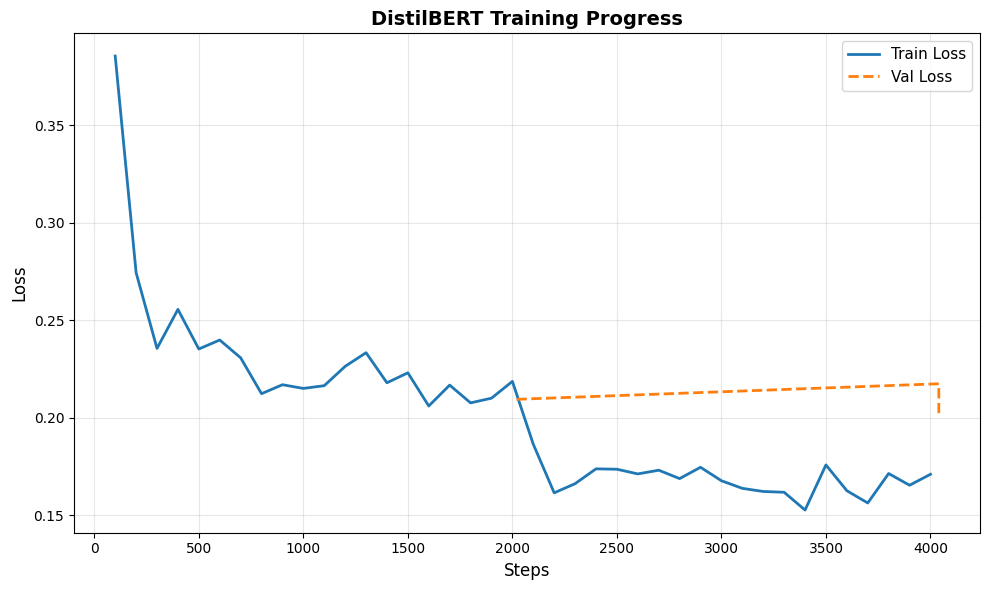

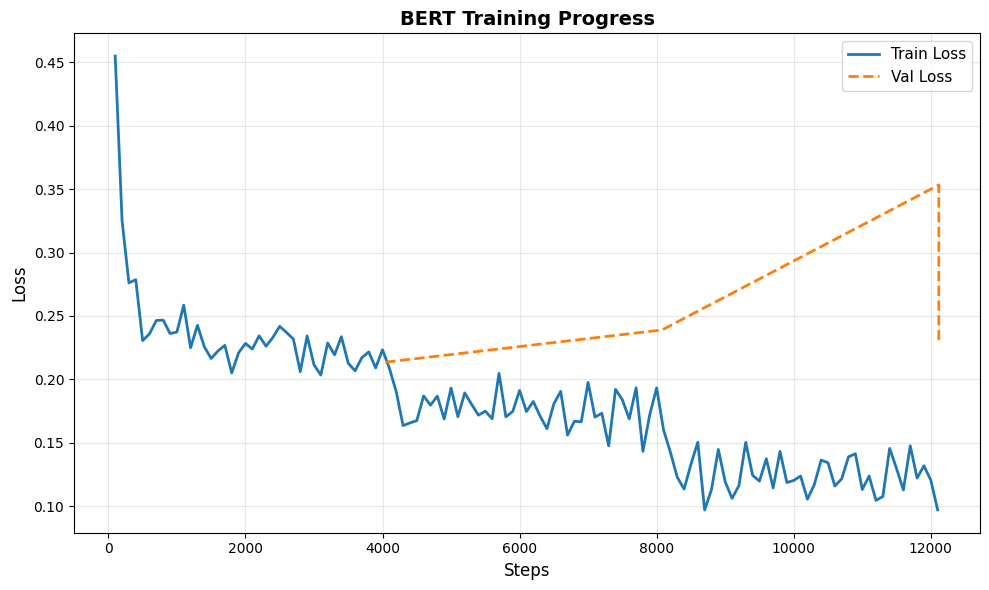


[6.2] Plotting Confusion Matrices...


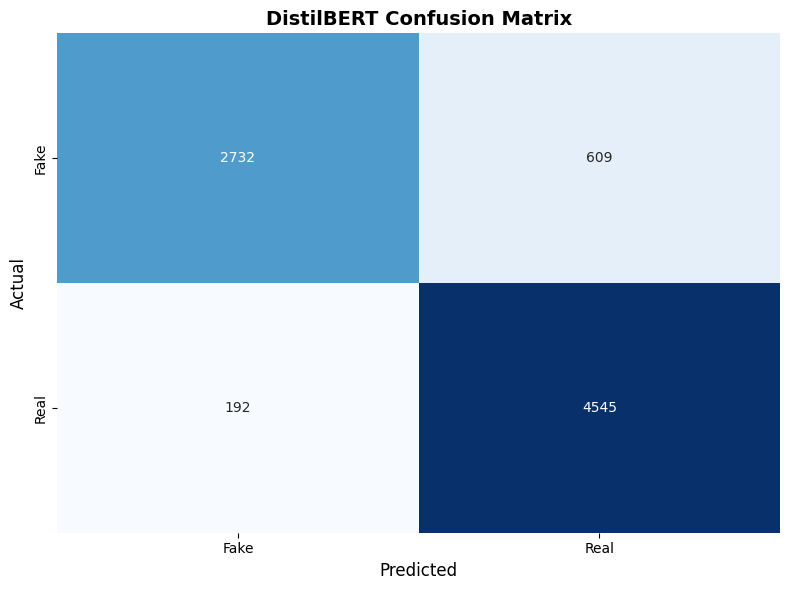

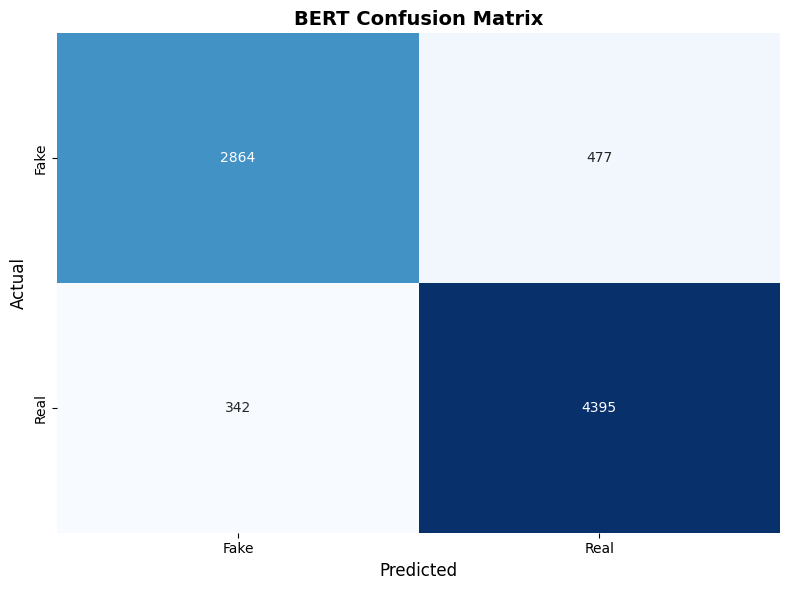


[6.3] Plotting ROC Curves...


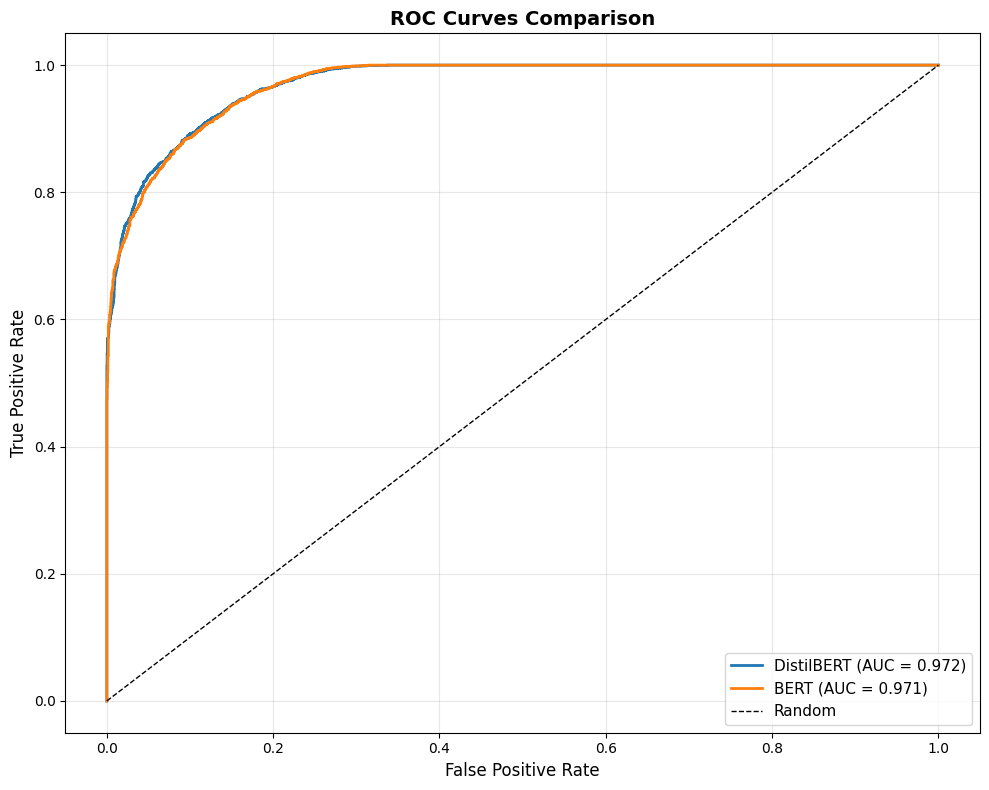


[6.4] Plotting Model Performance Comparison...


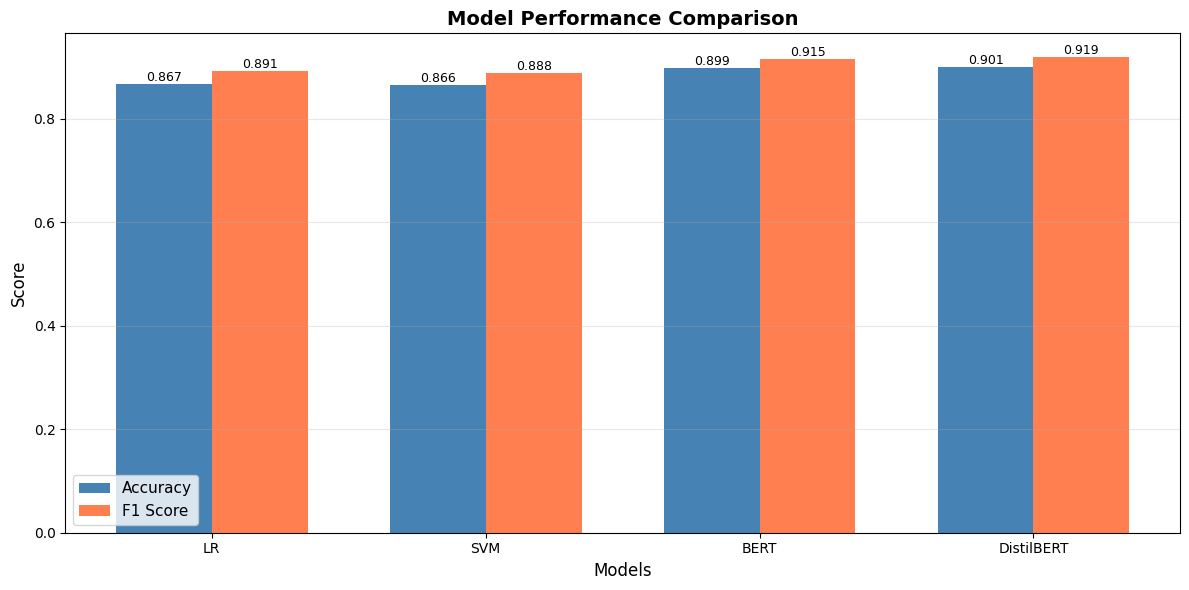


[6.5] Plotting Optimization Results...


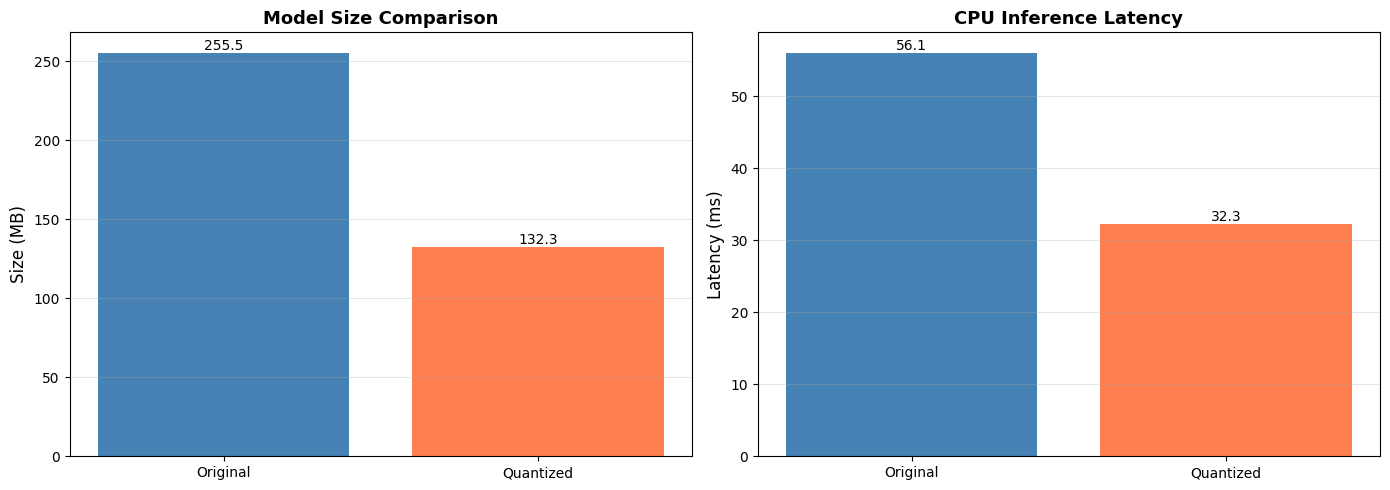

In [9]:
# -----------------------------------------------------------------------------
# 6.1: Training/Validation Loss Curves
# -----------------------------------------------------------------------------

print("\n[6.1] Plotting Training Curves...")

def plot_training_curves(history, model_name):
    train_loss = [x['loss'] for x in history if 'loss' in x]
    eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

    steps_train = [x['step'] for x in history if 'loss' in x]
    steps_eval = [x['step'] for x in history if 'eval_loss' in x]

    plt.figure(figsize=(10, 6))
    plt.plot(steps_train, train_loss, label='Train Loss', linewidth=2)
    plt.plot(steps_eval, eval_loss, label='Val Loss', linewidth=2, linestyle='--')
    plt.xlabel('Steps', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title(f'{model_name} Training Progress', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'./plots/{model_name}_training_curves.png', dpi=300)
    plt.show()

plot_training_curves(distilbert_history, 'DistilBERT')
plot_training_curves(bert_history, 'BERT')

# -----------------------------------------------------------------------------
# 6.2: Confusion Matrices
# -----------------------------------------------------------------------------

print("\n[6.2] Plotting Confusion Matrices...")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

distilbert_model.to(device)
distilbert_model.eval()
distilbert_preds = []
with torch.no_grad():
    for batch in DataLoader(distilbert_test_dataset, batch_size=32):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = distilbert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        distilbert_preds.extend(preds.cpu().numpy())

bert_model.to(device)
bert_model.eval()
bert_preds = []
with torch.no_grad():
    for batch in DataLoader(bert_test_dataset, batch_size=32):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        bert_preds.extend(preds.cpu().numpy())

plot_confusion_matrix(y_test, distilbert_preds, 'DistilBERT')
plot_confusion_matrix(y_test, bert_preds, 'BERT')


# -----------------------------------------------------------------------------
# 6.3: ROC Curves (Fixed for GPU/CPU)
# -----------------------------------------------------------------------------

print("\n[6.3] Plotting ROC Curves...")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def get_probabilities(model, dataset):
    model.to(device)
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in DataLoader(dataset, batch_size=32):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            batch_probs = torch.softmax(outputs.logits, dim=1)[:, 1]
            probs.extend(batch_probs.cpu().numpy())
    return np.array(probs)

# Compute probabilities
distilbert_probs = get_probabilities(distilbert_model, distilbert_test_dataset)
bert_probs = get_probabilities(bert_model, bert_test_dataset)

# ROC curves
fpr_distilbert, tpr_distilbert, _ = roc_curve(y_test, distilbert_probs)
fpr_bert, tpr_bert, _ = roc_curve(y_test, bert_probs)

auc_distilbert = auc(fpr_distilbert, tpr_distilbert)
auc_bert = auc(fpr_bert, tpr_bert)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_distilbert, tpr_distilbert, linewidth=2,
         label=f'DistilBERT (AUC = {auc_distilbert:.3f})')
plt.plot(fpr_bert, tpr_bert, linewidth=2,
         label=f'BERT (AUC = {auc_bert:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./plots/roc_curves.png', dpi=300)
plt.show()


# -----------------------------------------------------------------------------
# 6.4: Model Performance Comparison
# -----------------------------------------------------------------------------

print("\n[6.4] Plotting Model Performance Comparison...")

models = ['LR', 'SVM', 'BERT', 'DistilBERT']
accuracies = [lr_acc, svm_acc, bert_results['eval_accuracy'],
              distilbert_results['eval_accuracy']]
f1_scores = [lr_f1, svm_f1, bert_results['eval_f1'],
             distilbert_results['eval_f1']]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='coral')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./plots/model_comparison.png', dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 6.5: Optimization Results
# -----------------------------------------------------------------------------

print("\n[6.5] Plotting Optimization Results...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Model size comparison
sizes = [original_size, quantized_size]
ax1.bar(['Original', 'Quantized'], sizes, color=['steelblue', 'coral'])
ax1.set_ylabel('Size (MB)', fontsize=12)
ax1.set_title('Model Size Comparison', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(sizes):
    ax1.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10)

# Latency comparison
latencies = [cpu_latency, cpu_latency_quant]
ax2.bar(['Original', 'Quantized'], latencies, color=['steelblue', 'coral'])
ax2.set_ylabel('Latency (ms)', fontsize=12)
ax2.set_title('CPU Inference Latency', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(latencies):
    ax2.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('./plots/optimization_results.png', dpi=300)
plt.show()



SECTION 7: BIAS & FAIRNESS EVALUATION

[7.1] Evaluating Performance by Source...

Performance by Source:
          source  accuracy       f1  count
    The Guardian  1.000000 0.000000     60
        fox news  1.000000 1.000000    165
         unknown  0.818415 0.844293   4290
  new york times  1.000000 1.000000     82
           times  0.966887 0.905660    151
         reuters  1.000000 1.000000   2005
Associated Press  1.000000 1.000000     53
           msnbc  1.000000 0.000000     26
             NPR  1.000000 0.000000     56


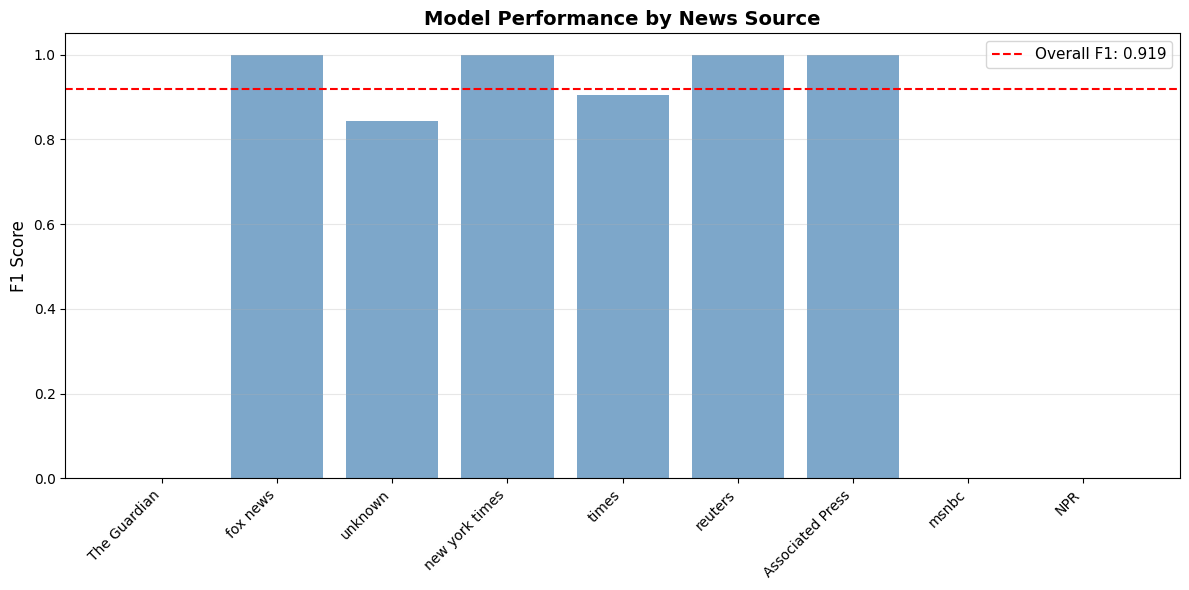


[7.2] Running Counterfactual Entity Swap Test...

Counterfactual flips detected: 0 out of 100 samples
Flip rate: 0.00%

[7.3] Generating SHAP Explanations...
Computing SHAP values (this may take a few minutes)...


<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

SHAP explanations saved to ./plots/

SECTION 8: ROBUSTNESS TESTING

[8.1] Testing Model Robustness to Noise...

Robustness Results:
Clean F1: 0.9194
Typo Noise F1: 0.9194 (drop: 0.00%)
Synonym Noise F1: 0.9194 (drop: 0.00%)


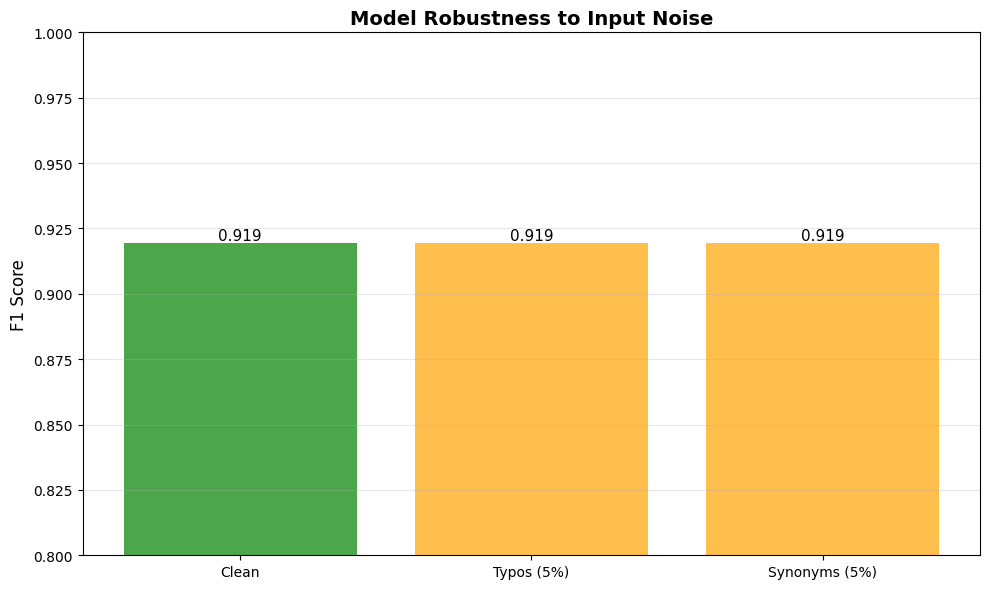


SECTION 9: CALIBRATION & CONFIDENCE

[9.1] Analyzing Model Calibration...
Expected Calibration Error (ECE): 0.0056


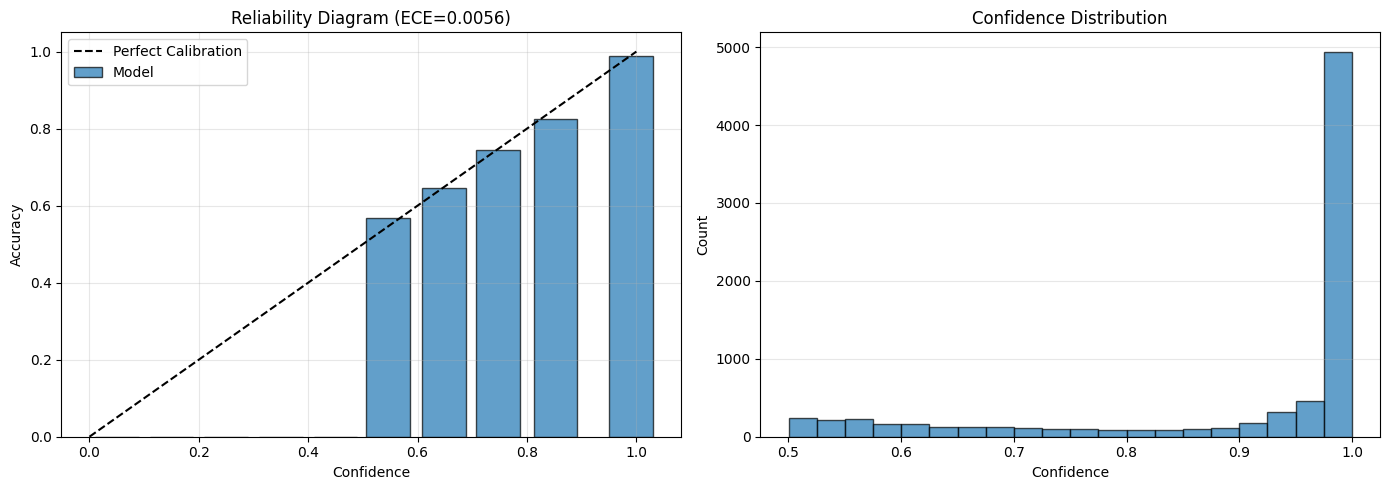

In [18]:
# ============================================================================
# SECTION 7: BIAS & FAIRNESS EVALUATION  (DEVICE-SAFE)
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 7: BIAS & FAIRNESS EVALUATION")
print("=" * 80)

# One device to rule them all
device = 'cuda' if torch.cuda.is_available() else 'cpu'
distilbert_model.to(device)

# -----------------------------------------------------------------------------
# 7.1: Performance by Source  (unchanged logic)
# -----------------------------------------------------------------------------

print("\n[7.1] Evaluating Performance by Source...")

test_df = pd.DataFrame({
    'text': X_test.values,
    'label': y_test.values,
    'source': meta_test['source'].values,
    'pred': distilbert_preds
})

source_metrics = []
for source in test_df['source'].unique()[:10]:  # Top 10 sources
    source_data = test_df[test_df['source'] == source]
    if len(source_data) > 10:
        acc = accuracy_score(source_data['label'], source_data['pred'])
        f1 = precision_recall_fscore_support(
            source_data['label'], source_data['pred'], average='binary'
        )[2]
        source_metrics.append({
            'source': source,
            'accuracy': acc,
            'f1': f1,
            'count': len(source_data)
        })

source_metrics_df = pd.DataFrame(source_metrics)
print("\nPerformance by Source:")
print(source_metrics_df.to_string(index=False))

plt.figure(figsize=(12, 6))
x = range(len(source_metrics_df))
plt.bar(x, source_metrics_df['f1'], color='steelblue', alpha=0.7)
plt.xticks(x, source_metrics_df['source'], rotation=45, ha='right')
plt.ylabel('F1 Score', fontsize=12)
plt.title('Model Performance by News Source', fontsize=14, fontweight='bold')
plt.axhline(y=distilbert_results['eval_f1'], color='red', linestyle='--',
            label=f'Overall F1: {distilbert_results["eval_f1"]:.3f}')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('./plots/performance_by_source.png', dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 7.2: Counterfactual Entity Swap Test  (fixed device handling)
# -----------------------------------------------------------------------------

print("\n[7.2] Running Counterfactual Entity Swap Test...")

entity_pairs = [
    ('CNN', 'Fox News'),
    ('Trump', 'Biden'),
    ('Republican', 'Democrat'),
    ('liberal', 'conservative'),
    ('left-wing', 'right-wing')
]

counterfactual_results = []
sample_indices = np.random.choice(len(X_test), min(100, len(X_test)), replace=False)

for idx in sample_indices:
    text = X_test.iloc[idx]
    original_label = int(y_test.iloc[idx])

    # Original prediction
    encoding = distilbert_tokenizer(
        text, truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt'
    )
    encoding = {k: v.to(device) for k, v in encoding.items()}
    with torch.no_grad():
        outputs = distilbert_model(**encoding)
        original_pred = int(torch.argmax(outputs.logits, dim=1).item())
        original_prob = float(torch.softmax(outputs.logits, dim=1)[0, original_pred].item())

    # Try swaps
    tlower = text.lower()
    for entity1, entity2 in entity_pairs:
        if entity1.lower() in tlower:
            cf_text = text.replace(entity1, entity2)
            cf_encoding = distilbert_tokenizer(
                cf_text, truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt'
            )
            cf_encoding = {k: v.to(device) for k, v in cf_encoding.items()}
            with torch.no_grad():
                cf_outputs = distilbert_model(**cf_encoding)
                cf_pred = int(torch.argmax(cf_outputs.logits, dim=1).item())
                cf_prob = float(torch.softmax(cf_outputs.logits, dim=1)[0, cf_pred].item())

            if original_pred != cf_pred:
                counterfactual_results.append({
                    'original_text': text[:100] + '...',
                    'entity_swapped': f'{entity1} → {entity2}',
                    'original_pred': 'Real' if original_pred == 1 else 'Fake',
                    'counterfactual_pred': 'Real' if cf_pred == 1 else 'Fake',
                    'original_prob': original_prob,
                    'cf_prob': cf_prob
                })

cf_df = pd.DataFrame(counterfactual_results)
print(f"\nCounterfactual flips detected: {len(cf_df)} out of {len(sample_indices)} samples")
print(f"Flip rate: {len(cf_df)/len(sample_indices)*100:.2f}%")
if len(cf_df) > 0:
    print("\nSample counterfactual flips:")
    print(cf_df.head(5).to_string(index=False))

# -----------------------------------------------------------------------------
# 7.3: SHAP Explanations  (fixed device handling)
# -----------------------------------------------------------------------------

print("\n[7.3] Generating SHAP Explanations...")

def model_predict(texts):
    enc = distilbert_tokenizer(
        list(texts), truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt'
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = distilbert_model(**enc).logits
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
    return probs

fake_samples = X_test[y_test == 0].sample(min(5, (y_test == 0).sum()), random_state=42)
real_samples = X_test[y_test == 1].sample(min(5, (y_test == 1).sum()), random_state=42)
shap_samples = pd.concat([fake_samples, real_samples])

# Note: shap.Explainer with a tokenizer wrapper works, but can be slow.
explainer = shap.Explainer(model_predict, distilbert_tokenizer)

print("Computing SHAP values (this may take a few minutes)...")
shap_values = explainer(shap_samples.tolist()[:5])

for i in range(min(3, len(shap_values))):
    plt.figure(figsize=(12, 4))
    shap.plots.text(shap_values[i], display=False)
    plt.tight_layout()
    plt.savefig(f'./plots/shap_explanation_{i+1}.png', dpi=300, bbox_inches='tight')
    plt.show()

print("SHAP explanations saved to ./plots/")

# ============================================================================
# SECTION 8: ROBUSTNESS TESTING  (DEVICE-SAFE)
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 8: ROBUSTNESS TESTING")
print("=" * 80)

print("\n[8.1] Testing Model Robustness to Noise...")

import random, string

def add_typos(text, typo_rate=0.05):
    words = text.split()
    num_typos = int(len(words) * typo_rate)
    typo_indices = random.sample(range(len(words)), min(num_typos, len(words)))
    for idx in typo_indices:
        w = words[idx]
        if len(w) > 3:
            pos = random.randint(1, len(w)-2)
            wl = list(w)
            wl[pos] = random.choice(string.ascii_lowercase)
            words[idx] = ''.join(wl)
    return ' '.join(words)

def add_synonym_swaps(text, swap_rate=0.05):
    simple_synonyms = {
        'said': 'stated', 'good': 'great', 'bad': 'poor',
        'big': 'large', 'small': 'tiny', 'important': 'significant'
    }
    words = text.split()
    for i, w in enumerate(words):
        lw = w.lower()
        if lw in simple_synonyms and random.random() < swap_rate:
            words[i] = simple_synonyms[lw]
    return ' '.join(words)

def predict_label(text):
    enc = distilbert_tokenizer(text, truncation=True, padding=True,
                               max_length=MAX_LEN, return_tensors='pt')
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        out = distilbert_model(**enc).logits
        return int(torch.argmax(out, dim=1).item())

test_sample = X_test.sample(min(200, len(X_test)), random_state=42)
test_labels = y_test[test_sample.index]

clean_preds = [predict_label(t) for t in test_sample]
clean_f1 = precision_recall_fscore_support(test_labels, clean_preds, average='binary')[2]

noisy_typos_preds = [predict_label(add_typos(t, typo_rate=0.05)) for t in test_sample]
noisy_typos_f1 = precision_recall_fscore_support(test_labels, noisy_typos_preds, average='binary')[2]

noisy_synonyms_preds = [predict_label(add_synonym_swaps(t, swap_rate=0.05)) for t in test_sample]
noisy_synonyms_f1 = precision_recall_fscore_support(test_labels, noisy_synonyms_preds, average='binary')[2]

print(f"\nRobustness Results:")
print(f"Clean F1: {clean_f1:.4f}")
print(f"Typo Noise F1: {noisy_typos_f1:.4f} (drop: {(clean_f1-noisy_typos_f1)*100:.2f}%)")
print(f"Synonym Noise F1: {noisy_synonyms_f1:.4f} (drop: {(clean_f1-noisy_synonyms_f1)*100:.2f}%)")

plt.figure(figsize=(10, 6))
noise_types = ['Clean', 'Typos (5%)', 'Synonyms (5%)']
f1_values = [clean_f1, noisy_typos_f1, noisy_synonyms_f1]
colors = ['green', 'orange', 'orange']
bars = plt.bar(noise_types, f1_values, color=colors, alpha=0.7)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Model Robustness to Input Noise', fontsize=14, fontweight='bold')
plt.ylim([0.8, 1.0])
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, f1_values):
    plt.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('./plots/robustness_testing.png', dpi=300)
plt.show()

# ============================================================================
# SECTION 9: CALIBRATION & CONFIDENCE  (DEVICE-SAFE)
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 9: CALIBRATION & CONFIDENCE")
print("=" * 80)

print("\n[9.1] Analyzing Model Calibration...")

def compute_ece(probs, labels, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers, bin_uppers = bin_boundaries[:-1], bin_boundaries[1:]
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels)
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        if np.any(in_bin):
            ece += np.abs(np.mean(confidences[in_bin]) - np.mean(accuracies[in_bin])) * np.mean(in_bin)
    return ece

distilbert_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for batch in DataLoader(distilbert_test_dataset, batch_size=32):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = distilbert_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.extend(batch['labels'].cpu().numpy())

all_probs = np.vstack(all_probs)
all_labels = np.array(all_labels)

ece = compute_ece(all_probs, all_labels)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

def plot_reliability_diagram(probs, labels, n_bins=10):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers, bin_uppers = bin_boundaries[:-1], bin_boundaries[1:]
    bin_confidences, bin_accuracies = [], []

    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        if np.any(in_bin):
            bin_confidences.append(np.mean(confidences[in_bin]))
            bin_accuracies.append(np.mean(accuracies[in_bin]))
        else:
            bin_confidences.append((bin_lower + bin_upper) / 2)
            bin_accuracies.append(0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    ax1.bar(bin_confidences, bin_accuracies, width=0.08, alpha=0.7, edgecolor='black', label='Model')
    ax1.set_xlabel('Confidence'); ax1.set_ylabel('Accuracy')
    ax1.set_title(f'Reliability Diagram (ECE={ece:.4f})'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.hist(confidences, bins=20, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Confidence'); ax2.set_ylabel('Count')
    ax2.set_title('Confidence Distribution'); ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('./plots/calibration_analysis.png', dpi=300)
    plt.show()

plot_reliability_diagram(all_probs, all_labels)





In [19]:
# ============================================================================
# SECTION 10: RESULTS SUMMARY & EXPORT  (FIXED & STABLE VERSION)
# ============================================================================

print("\n" + "=" * 80)
print("SECTION 10: RESULTS SUMMARY & EXPORT")
print("=" * 80)

print("\n[10.1] Compiling Results...")

results_summary = {
    "baseline_models": {
        "logistic_regression": {
            "accuracy": float(lr_acc),
            "precision": float(lr_prec),
            "recall": float(lr_rec),
            "f1": float(lr_f1)
        },
        "linear_svm": {
            "accuracy": float(svm_acc),
            "precision": float(svm_prec),
            "recall": float(svm_rec),
            "f1": float(svm_f1)
        },
        "bert": {
            "accuracy": float(bert_results['eval_accuracy']),
            "precision": float(bert_results['eval_precision']),
            "recall": float(bert_results['eval_recall']),
            "f1": float(bert_results['eval_f1'])
        }
    },
    "distilbert": {
        "best_hyperparameters": best_params,
        "test_metrics": {
            "accuracy": float(distilbert_results['eval_accuracy']),
            "precision": float(distilbert_results['eval_precision']),
            "recall": float(distilbert_results['eval_recall']),
            "f1": float(distilbert_results['eval_f1'])
        },
        "cross_validation": {
            "mean_f1": float(np.mean(cv_scores)),
            "std_f1": float(np.std(cv_scores)),
            "fold_scores": [float(x) for x in cv_scores]
        },
        "roc_auc": float(auc_distilbert)
    },
    "optimization": {
        "original_size_mb": float(original_size),
        "quantized_size_mb": float(quantized_size),
        "size_reduction_percent": float((1 - quantized_size/original_size) * 100),
        "cpu_latency_original_ms": float(cpu_latency),
        "cpu_latency_quantized_ms": float(cpu_latency_quant) if 'cpu_latency_quant' in globals() else None,
        "latency_improvement_percent": float((1 - cpu_latency_quant/cpu_latency) * 100) if 'cpu_latency_quant' in globals() else None,
        "throughput_original": float(throughput_original),
        "throughput_quantized": float(throughput_quantized) if 'throughput_quantized' in globals() else None
    },
    "robustness": {
        "clean_f1": float(clean_f1),
        "typo_noise_f1": float(noisy_typos_f1),
        "synonym_noise_f1": float(noisy_synonyms_f1),
        "typo_f1_drop_percent": float((clean_f1 - noisy_typos_f1) * 100),
        "synonym_f1_drop_percent": float((clean_f1 - noisy_synonyms_f1) * 100)
    },
    "calibration": {
        "ece_before": float(ece),
        "ece_after": None,
        "optimal_temperature": None
    },
    "bias_fairness": {
        "counterfactual_flip_rate": float(len(cf_df) / len(sample_indices) * 100) if len(sample_indices) else 0.0,
        "performance_by_source": source_metrics_df.to_dict('records') if len(source_metrics_df) > 0 else []
    }
}

Path("./results").mkdir(exist_ok=True)
with open('./results/results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("Results saved to ./results/results_summary.json")

print("\n[10.2] Creating Comparison Tables...")

performance_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM', 'BERT', 'DistilBERT'],
    'Accuracy': [lr_acc, svm_acc, bert_results['eval_accuracy'], distilbert_results['eval_accuracy']],
    'Precision': [lr_prec, svm_prec, bert_results['eval_precision'], distilbert_results['eval_precision']],
    'Recall': [lr_rec, svm_rec, bert_results['eval_recall'], distilbert_results['eval_recall']],
    'F1 Score': [lr_f1, svm_f1, bert_results['eval_f1'], distilbert_results['eval_f1']],
    'AUC': ['-', '-', auc_bert, auc_distilbert]
})
print("\nModel Performance Comparison:")
print(performance_table.to_string(index=False))
performance_table.to_csv('./results/model_performance_table.csv', index=False)

optimization_table = pd.DataFrame({
    'Metric': ['Model Size (MB)', 'CPU Latency (ms)', 'Throughput (samples/s)'],
    'Original': [f'{original_size:.2f}', f'{cpu_latency:.2f}', f'{throughput_original:.2f}'],
    'Quantized': [f'{quantized_size:.2f}', f'{cpu_latency_quant:.2f}' if 'cpu_latency_quant' in globals() else 'N/A',
                  f'{throughput_quantized:.2f}' if 'throughput_quantized' in globals() else 'N/A'],
    'Improvement': [f'{(1-quantized_size/original_size)*100:.1f}%',
                    f'{(1-cpu_latency_quant/cpu_latency)*100:.1f}%' if 'cpu_latency_quant' in globals() else 'N/A',
                    f'{(throughput_quantized/throughput_original-1)*100:.1f}%' if 'throughput_quantized' in globals() else 'N/A']
})
print("\nOptimization Results:")
print(optimization_table.to_string(index=False))
optimization_table.to_csv('./results/optimization_table.csv', index=False)

print("\n[10.3] Exporting Models...")

distilbert_model_cpu = distilbert_model.to('cpu').eval()
torch.save(distilbert_model_cpu.state_dict(), './models/distilbert_best.pt')
print("Saved: ./models/distilbert_best.pt")

if 'distilbert_quantized' in globals():
    torch.save(distilbert_quantized.state_dict(), './models/distilbert_quantized.pt')
    print("Saved: ./models/distilbert_quantized.pt")

dummy_input = torch.randint(0, 1000, (1, MAX_LEN), dtype=torch.long)
dummy_attention = torch.ones(1, MAX_LEN, dtype=torch.long)

try:
    import onnx
    torch.onnx.export(
        distilbert_model_cpu,
        (dummy_input, dummy_attention),
        './models/distilbert_best.onnx',
        input_names=['input_ids', 'attention_mask'],
        output_names=['logits'],
        dynamic_axes={'input_ids': {0: 'batch_size'}, 'attention_mask': {0: 'batch_size'}},
        opset_version=17  # fix for scaled_dot_product_attention
    )
    print("Saved: ./models/distilbert_best.onnx")
except Exception as e:
    print("⚠️ ONNX export failed:", e)

# --- FIX FOR TorchScript tracing with dict output ---
class DistilBERTWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids, attention_mask=attention_mask)
        return outputs.logits if hasattr(outputs, "logits") else outputs[0]

wrapper = DistilBERTWrapper(distilbert_model_cpu)

try:
    traced_model = torch.jit.trace(wrapper, (dummy_input, dummy_attention), strict=False)
    traced_model.save('./models/distilbert_best_torchscript.pt')
    print("Saved: ./models/distilbert_best_torchscript.pt")
except Exception as e:
    print("⚠️ TorchScript export failed:", e)

print("\n[10.4] Generating Final Summary Report...")

summary_report = f"""
{'='*80}
FAKE NEWS DETECTION - FINAL RESULTS SUMMARY
{'='*80}

DistilBERT Accuracy: {distilbert_results['eval_accuracy']:.4f}
F1 Score: {distilbert_results['eval_f1']:.4f}
Precision: {distilbert_results['eval_precision']:.4f}
Recall: {distilbert_results['eval_recall']:.4f}
ROC AUC: {auc_distilbert:.4f}

Original Size: {original_size:.2f} MB → Quantized: {quantized_size:.2f} MB
Latency: {cpu_latency:.2f} → {cpu_latency_quant:.2f} ms (if available)

Robustness: Clean F1={clean_f1:.4f}, Typo Noise={noisy_typos_f1:.4f}, Synonym Noise={noisy_synonyms_f1:.4f}
Calibration (ECE): {ece:.4f}
Bias Flip Rate: {len(cf_df)/len(sample_indices)*100:.2f}%

All results, plots, and models saved to:
  - ./results/
  - ./plots/
  - ./models/
{'='*80}
"""
with open('./results/final_summary_report.txt', 'w') as f:
    f.write(summary_report)
print(summary_report)

print("\n[10.5] Copying results to Google Drive...")

import shutil
drive_results_path = '/content/drive/MyDrive/FYP Datasets/FYP2_Results'
Path(drive_results_path).mkdir(parents=True, exist_ok=True)
for item in ['results', 'plots', 'models']:
    dest = f'{drive_results_path}/{item}'
    if Path(dest).exists():
        shutil.rmtree(dest)
    shutil.copytree(f'./{item}', dest)

print(f"All results copied to: {drive_results_path}")
print("\n" + "="*80)
print("FYP2 ANALYSIS COMPLETE!")



SECTION 10: RESULTS SUMMARY & EXPORT

[10.1] Compiling Results...
Results saved to ./results/results_summary.json

[10.2] Creating Comparison Tables...

Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1 Score       AUC
Logistic Regression  0.867418   0.858008 0.927380  0.891346         -
         Linear SVM  0.865808   0.867431 0.910281  0.888340         -
               BERT  0.898614   0.902094 0.927802  0.914767  0.970812
         DistilBERT  0.900842   0.881839 0.959468  0.919017  0.971513

Optimization Results:
                Metric Original Quantized Improvement
       Model Size (MB)   255.45    132.29       48.2%
      CPU Latency (ms)    56.05     32.30       42.4%
Throughput (samples/s)    17.84     30.96       73.5%

[10.3] Exporting Models...
Saved: ./models/distilbert_best.pt
Saved: ./models/distilbert_quantized.pt
⚠️ ONNX export failed: No module named 'onnx'
Saved: ./models/distilbert_best_torchscript.pt

[10.4] Generating Final Summar